TT ML Entrega Final

In [41]:
# Importar paquetes
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

In [42]:
# 1. Selección y carga del dataset

file_path = "diabetes.csv"
print("Descargando datos desde National Institute of Diabetes and Digestive and Kidney Diseases...")

df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "uciml/pima-indians-diabetes-database",
  file_path
)

# Revisar que la carga es correcta
print("Se cargó la siguiente base de datos")
df.head()


Descargando datos desde National Institute of Diabetes and Digestive and Kidney Diseases...
Using Colab cache for faster access to the 'pima-indians-diabetes-database' dataset.
Se cargó la siguiente base de datos


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


# Análisis de Datos Exploratorio

In [43]:
# 2. Exploración inicial: selección de variables relevantes
# Dado que son solo 8 columnas con información médica relevante, se usan todas.

print(df.columns)


Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')


#### Variables
En este conjunto de datos, la variable dependiente es 'Outcome' y las otras ocho variables ('Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age') son independientes.

In [44]:
# 3. Limpieza de datos nulos o faltantes.

#Buscar valores nulos
print("¿Hay valores nulos?", df.isnull().values.any())

#Ver cantidad de instancias/filas
print(f"Hay {len(df)} filas no nulas.")

#Eliminar valores nulos que hubiera sin identificar.
df_diabetes = df.dropna()

print(f"La df_diabetes tiene información limpia de {len(df_diabetes)} casos.")

¿Hay valores nulos? False
Hay 768 filas no nulas.
La df_diabetes tiene información limpia de 768 casos.


# Estadística descriptiva

In [45]:
# Valores estadísticos generales de la df_diabetes
df_diabetes.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


### Observaciones parciales:
- El valor mínimo para 7 de las 8 variables independientes es 0.
- Muchos de estos valores corresponden a niveles de insulina, glucosa, presión arterial (BP), índice de masa corporal (BMI), etc. que no pueden ser nulos.
- Parece que varios valores faltantes o erróneos fueron imputados como 0.

In [46]:
# ¿Cuántos valores nulos aparecen en cada variable/columna?
print(f"Total de valores 0 por columna {(df_diabetes == 0).sum().to_dict()}")

Total de valores 0 por columna {'Pregnancies': 111, 'Glucose': 5, 'BloodPressure': 35, 'SkinThickness': 227, 'Insulin': 374, 'BMI': 11, 'DiabetesPedigreeFunction': 0, 'Age': 0, 'Outcome': 500}


### Limpieza de valores nulos
- Quitar datos con valores 0 de glucosa, presión arterial, IMC e insulina.
- Crear un nuevo dataset antes de continuar el análisis.


In [47]:
# Creación de nuevo dataset
# df_diabs que excluye todas las filas que tienen valor 0 en las columnas
# Glucose, BP, BMI y Insulin

drop_Glu=df_diabetes.index[df_diabetes.Glucose == 0].tolist()
drop_BP=df_diabetes.index[df_diabetes.BloodPressure == 0].tolist()
drop_Ins = df_diabetes.index[df_diabetes.Insulin==0].tolist()
drop_BMI = df_diabetes.index[df_diabetes.BMI==0].tolist()

c= drop_Glu + drop_BP + drop_Ins + drop_BMI

df_diabs=df_diabetes.drop(df_diabetes.index[c])
print("El dataset limpio es df_diabs y consta de las siguientes columnas")
print(df_diabs.info())

El dataset limpio es df_diabs y consta de las siguientes columnas
<class 'pandas.core.frame.DataFrame'>
Index: 392 entries, 3 to 765
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               392 non-null    int64  
 1   Glucose                   392 non-null    int64  
 2   BloodPressure             392 non-null    int64  
 3   SkinThickness             392 non-null    int64  
 4   Insulin                   392 non-null    int64  
 5   BMI                       392 non-null    float64
 6   DiabetesPedigreeFunction  392 non-null    float64
 7   Age                       392 non-null    int64  
 8   Outcome                   392 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 30.6 KB
None


#### Comentarios sobre df_diabs:
- La df original se redujo casi a la mitad pero df_diabs es mucho más informativa porque contiene datos más relevantes para el modelado.
- Alternativa: se pueden tomar esos 0 como NaN (valores faltantes) y se pueden imputar usando KNN o imputandolos con las medianas para crear un dataset más balanceado.

## Exploración estadística y visual

In [48]:
# Valores estadísticos generales de la df_diabs
print("Estadísticas descriptivas de los casos de diabetes: ")
df_diabs.describe()

Estadísticas descriptivas de los casos de diabetes: 


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,3.301020,122.627551,70.663265,29.145408,156.056122,33.086224,0.523046,30.864796,0.331633
std,3.211424,30.860781,12.496092,10.516424,118.841690,7.027659,0.345488,10.200777,0.471401
min,0.000000,56.000000,24.000000,7.000000,14.000000,18.200000,0.085000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,21.000000,76.750000,28.400000,0.269750,23.000000,0.000000
50%,2.000000,119.000000,70.000000,29.000000,125.500000,33.200000,0.449500,27.000000,0.000000
75%,5.000000,143.000000,78.000000,37.000000,190.000000,37.100000,0.687000,36.000000,1.000000
max,17.000000,198.000000,110.000000,63.000000,846.000000,67.100000,2.420000,81.000000,1.000000


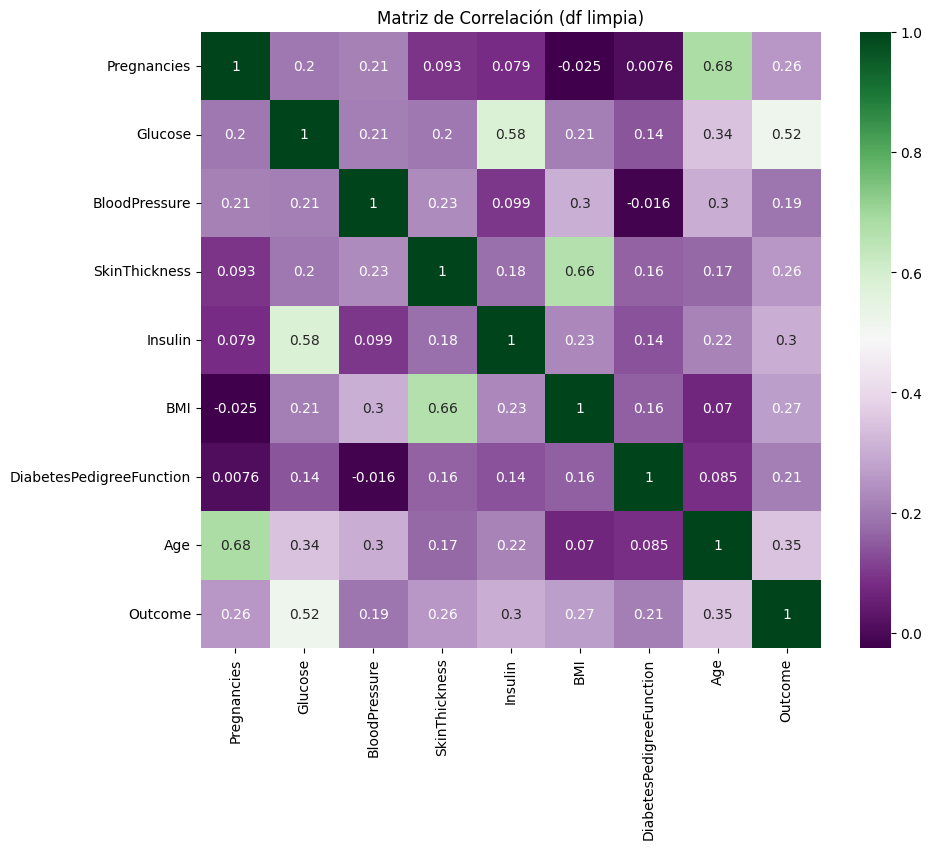

In [49]:
# Exploración visual inicial (matriz de correlación)
# Con la df limpia (df_diabs):
plt.figure(figsize=(10, 8))
sns.heatmap(df_diabs.corr(), annot=True, cmap='PRGn')
plt.title('Matriz de Correlación (df limpia)')
plt.show()


#### Búsqueda de variables relevantes:
- Valor de correlación mayor a 0,5 (en el gráfico, se representa con colores que van del blanco al verde oscuro).
- Con ese criterio, deberían considerarse: insulina, BMI y edad.


### Exploración visual (Distribución de clases)


¿Cuántos casos de diabetes se registran en la base de datos limpia?



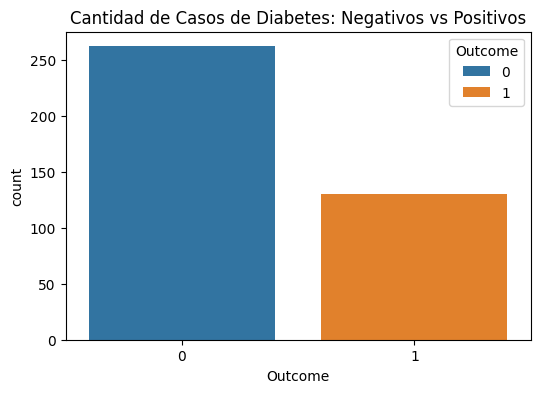


 Se registran 130 casos positivos y 262 casos negativos


In [50]:
print("¿Cuántos casos de diabetes se registran en la base de datos limpia?\n")

plt.figure(figsize=(6, 4))
sns.countplot(x='Outcome', data=df_diabs, hue='Outcome')
plt.title("Cantidad de Casos de Diabetes: Negativos vs Positivos")
plt.show()

print(f"\n Se registran {(df_diabs['Outcome']== 1).sum()} casos positivos y {(df_diabs['Outcome']==0).sum()} casos negativos")

## Elección del Modelo

El problema es de **clasificación binaria**: cada caso de posible diabetes evaluado debe ser catalogado como **positivo (1)** o **negativo (0)** en función de sus condiciones clínicas y fisiológicas, i.e. los valores de las variables que registran datos biométricos (insulina, IMC, edad, etc).

Dado que lo que se busca es asignar una etiqueta discreta, por lo que los modelos de regresión lineal clásicos no son adecuados ya que no se busca predecir un valor numérico continuo.

Se eligen entonces dos modelos de clasificación complementarios:

1. **Regresión Logística**: modelo lineal de referencia para *clasificación binaria*. Produce probabilidades interpretables y permite analizar qué variables (pesos del modelo) influyen más en la decisión. Por su simplicidad, es útil como *baseline* para comparar con modelos más complejos.

2. **Random Forest (Bosque Aleatorio)**: conjunto de árboles de decisión que captura relaciones no lineales entre las variables (que la regresión logística no puede hacer). Es robusto frente a valores atípicos y no requiere un escalado estricto de las *features*. Resulta especialmente útil cuando las relaciones entre las variables predictoras y la variable objetivo no son puramente lineales, como es frecuente en datos biométricos.

La comparación entre ambos modelos permite evaluar si la complejidad adicional del Random Forest realmente mejora el rendimiento frente a la línea base de la Regresión Logística.

## Preparación de los datos para modelado

### División del dataset en conjuntos de entrenamiento y prueba.

In [51]:
#columnas =(df_diabs.columns).tolist()
#print(columnas)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Codificación
# Todas las variables (incluyendo la dependiente) son numéricas
# No hace falta codificar variables.

# 2. Separar las pistas (X) del resultado (y)
X = df_diabs[['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']]

y = df_diabs['Outcome']

# 3. Escalado de variables numéricas
scaler = StandardScaler()
X_escalado = scaler.fit_transform(X)

# 4. Dividir en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X_escalado, y, test_size=0.20, random_state=42)

print("Datos codificados, escalados y divididos.")


Datos codificados, escalados y divididos.


### Creación y aprendizaje del modelo de regresión logística.

In [52]:
from sklearn.linear_model import LogisticRegression

# 1. Creación el modelo 1
modelo_lr = LogisticRegression(max_iter=1000, random_state=42)

# 2.Aprendizaje: alimentación del modelo con datos de entrenamiento
modelo_lr.fit(X_train, y_train)

# 3. Revisión de pesos para ver qué variables consideró más importantes
pesos = pd.DataFrame({
    'Pistas biométricas': X.columns,
    'Importancia (Peso)': modelo_lr.coef_[0]
})
print("¿A qué le presta más atención el modelo para detectar diabetes?")
display(pesos)

¿A qué le presta más atención el modelo para detectar diabetes?


,Pistas biométricas,Importancia (Peso)
0,Pregnancies,0.362659
1,Glucose,1.126297
2,BloodPressure,0.124222
3,SkinThickness,0.221690
4,Insulin,0.131155
5,BMI,0.318195
6,DiabetesPedigreeFunction,0.408242
7,Age,0.199491


### Creación y aprendizaje de un modelo de "bosque aleatorio" (*random forest*).

In [53]:
from sklearn.ensemble import RandomForestClassifier

# Modelo 2: Random Forest (captura relaciones no lineales)
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_rf.fit(X_train, y_train)

# Importancia de variables segun Random Forest
importancias_rf = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': modelo_rf.feature_importances_
}).sort_values('Importancia', ascending=False)

print('Importancia de variables (Random Forest):')
display(importancias_rf)

Importancia de variables (Random Forest):


,Variable,Importancia
1,Glucose,0.256116
4,Insulin,0.157913
5,BMI,0.137334
7,Age,0.125492
6,DiabetesPedigreeFunction,0.094515
3,SkinThickness,0.077892
0,Pregnancies,0.076382
2,BloodPressure,0.074356


### Evaluación de modelos con métricas adecuadas

Por tratarse de un problema de clasificación, se utilizan las siguientes métricas:

- **Accuracy (Exactitud)**: proporción de predicciones correctas sobre el total.
- **Precision (Precisión)**: cantidad de casos de diabetes positivos reales de todos los que el modelo detectó como positivos.
- **Recall (Sensibilidad)**: cantidad de casos de diabetes que detectó el modelo de la totalidad de casos realmente positivos.
- **F1-score**: media armónica entre Precision y Recall. Es un valor entre 0 y 1 que resulta equilibrada cuando hay desbalance de clases.
- **Matriz de Confusión**: muestra explícitamente los verdaderos positivos/negativos y los falsos positivos/negativos.

   EVALUACION - REGRESION LOGISTICA
Accuracy : 0.7722
Precision: 0.6957
Recall   : 0.5926
F1-score : 0.6400

Reporte completo:
                  precision    recall  f1-score   support

    Sin diabetes       0.80      0.87      0.83        52
Posible diabetes       0.70      0.59      0.64        27

        accuracy                           0.77        79
       macro avg       0.75      0.73      0.74        79
    weighted avg       0.77      0.77      0.77        79



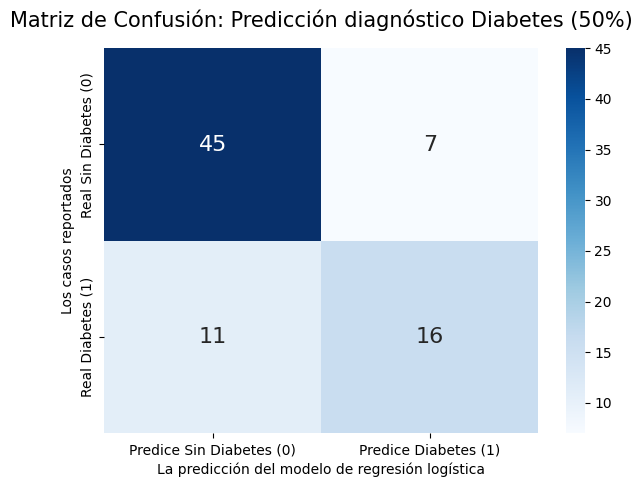

In [54]:
#Prueba del modelo de regresión logística

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# Generación de predicciones con conjunto de prueba
y_pred_lr = modelo_lr.predict(X_test)

# Metricas individuales
acc_lr  = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr)
rec_lr  = recall_score(y_test, y_pred_lr)
f1_lr   = f1_score(y_test, y_pred_lr)

print('='*40)
print('   EVALUACION - REGRESION LOGISTICA')
print('='*40)
print(f'Accuracy : {acc_lr:.4f}')
print(f'Precision: {prec_lr:.4f}')
print(f'Recall   : {rec_lr:.4f}')
print(f'F1-score : {f1_lr:.4f}')
print()
print('Reporte completo:')
print(classification_report(y_test, y_pred_lr, target_names=['Sin diabetes', 'Posible diabetes']))

# Visualización del rendimiento del modelo de regresión logística

cfm_log_diabs = confusion_matrix(y_test,y_pred_lr)

plt.figure(figsize=(7,5))
sns.heatmap(cfm_log_diabs, annot=True, fmt='d', cmap='Blues', annot_kws={"size": 16},
            xticklabels=['Predice Sin Diabetes (0)', 'Predice Diabetes (1)'],
            yticklabels=['Real Sin Diabetes (0)', 'Real Diabetes (1)'])

plt.title('Matriz de Confusión: Predicción diagnóstico Diabetes (50%)', fontsize=15, pad=15)
plt.ylabel('Los casos reportados')
plt.xlabel('La predicción del modelo de regresión logística')
plt.show()

   EVALUACION - RANDOM FOREST
Accuracy : 0.7848
Precision: 0.7083
Recall   : 0.6296
F1-score : 0.6667

Reporte completo:
                  precision    recall  f1-score   support

    Sin diabetes       0.82      0.87      0.84        52
Posible diabetes       0.71      0.63      0.67        27

        accuracy                           0.78        79
       macro avg       0.76      0.75      0.75        79
    weighted avg       0.78      0.78      0.78        79



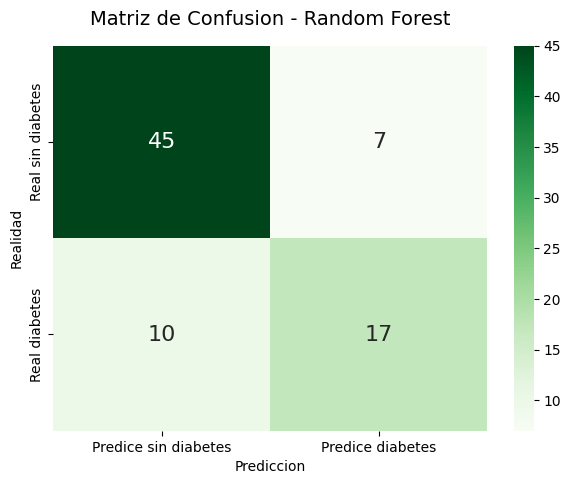

In [55]:
# Predicciones de Random Forest
y_pred_rf = modelo_rf.predict(X_test)

# Metricas individuales
acc_rf  = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf  = recall_score(y_test, y_pred_rf)
f1_rf   = f1_score(y_test, y_pred_rf)

print('='*35)
print('   EVALUACION - RANDOM FOREST')
print('='*35)
print(f'Accuracy : {acc_rf:.4f}')
print(f'Precision: {prec_rf:.4f}')
print(f'Recall   : {rec_rf:.4f}')
print(f'F1-score : {f1_rf:.4f}')
print()
print('Reporte completo:')
print(classification_report(y_test, y_pred_rf, target_names=['Sin diabetes', 'Posible diabetes']))

# Matriz de confusion
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', annot_kws={'size': 16},
            xticklabels=['Predice sin diabetes', 'Predice diabetes'],
            yticklabels=['Real sin diabetes', 'Real diabetes'])
plt.title('Matriz de Confusion - Random Forest', fontsize=14, pad=15)
plt.ylabel('Realidad')
plt.xlabel('Prediccion')
plt.show()

## Comparación de métricas

In [56]:
# Tabla comparativa de metricas
comparacion = pd.DataFrame({
    'Metrica': ['Accuracy', 'Precision', 'Recall', 'F1-score'],
    'Regresion Logistica': [acc_lr, prec_lr, rec_lr, f1_lr],
    'Random Forest': [acc_rf, prec_rf, rec_rf, f1_rf]
})

print('Comparacion de modelos en el conjunto de prueba:')
display(comparacion.style.format({'Regresion Logistica': '{:.4f}', 'Random Forest': '{:.4f}'}))

Comparacion de modelos en el conjunto de prueba:


,Metrica,Regresion Logistica,Random Forest
0,Accuracy,0.7722,0.7848
1,Precision,0.6957,0.7083
2,Recall,0.5926,0.6296
3,F1-score,0.6400,0.6667


### Validación Cruzada (Cross-Validation)
La evaluación con un solo conjunto de prueba puede ser engañosa si la división train/test resulta favorable o desfavorable por azar.

Para obtener una estimación más robusta del rendimiento real del modelo, se usa la "validación cruzada k-fold" (*k-fold cross-validation*), que divide los datos en k particiones (folds), entrena en k-1 y evalúa en la restante, rotando hasta que cada partición se use como test exactamente una vez.

StratifiedKFold (k=5) preserva la proporción de clases en cada partición, lo cual resulta fundamental en casos como el estudiado donde hay mucho desbalance (hay más del doble de casos negativos que positivos).

Se reportan  la media y desvío estándar de cada métrica.

In [57]:
from sklearn.model_selection import cross_validate, StratifiedKFold
import numpy as np

# Se definen 5 particiones estratificados
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Metricas a evaluar en cada partición
scoring = ['accuracy', 'precision', 'recall', 'f1']

# --- Regresion Logistica ---
cv_lr = cross_validate(modelo_lr, X_escalado, y, cv=cv, scoring=scoring)

print('='*55)
print('   VALIDACION CRUZADA - REGRESIÓN LOGÍSTICA (5-folds)')
print('='*55)
for metric in scoring:
    scores = cv_lr[f'test_{metric}']
    print(f'{metric:10s}: media = {scores.mean():.4f}  +/-  {scores.std():.4f}')

print()

# --- Random Forest ---
cv_rf = cross_validate(modelo_rf, X_escalado, y, cv=cv, scoring=scoring)

print('='*55)
print('   VALIDACION CRUZADA - RANDOM FOREST (5-folds)')
print('='*55)
for metric in scoring:
    scores = cv_rf[f'test_{metric}']
    print(f'{metric:10s}: media = {scores.mean():.4f}  +/-  {scores.std():.4f}')

   VALIDACION CRUZADA - REGRESIÓN LOGÍSTICA (5-folds)
accuracy  : media = 0.7780  +/-  0.0278
precision : media = 0.7220  +/-  0.0791
recall    : media = 0.5615  +/-  0.1131
f1        : media = 0.6215  +/-  0.0612

   VALIDACION CRUZADA - RANDOM FOREST (5-folds)
accuracy  : media = 0.7885  +/-  0.0463
precision : media = 0.7054  +/-  0.0567
recall    : media = 0.6077  +/-  0.1385
f1        : media = 0.6484  +/-  0.1009


| Observación | Conclusión |
|-----------|-------------|
| Random Forest tiene **media más alta** en Recall | Detecta más casos de diabetes que la Regresión Logística |
| Random Forest tiene **desvío más bajo** en precisión| Es más transparente al encontrar casos positivos reales |
| Random forest tiene **desvío más alto** en Recall y el f1| Su capacidad de detectar casos de diabetes varía según qué datos entreno |
| LogReg tiene **media más baja** en Recall | Detecta menos casos de diabetes que Random forest|
| LogReg tiene **desvío más alto** en precisión| Encuentra menos casos positivos reales |
| LogReg tiene **desvío más bajo** en Recall y el f1| Su capacidad de detectar casos de diabetes varía menos que Random forest según qué datos maneje |


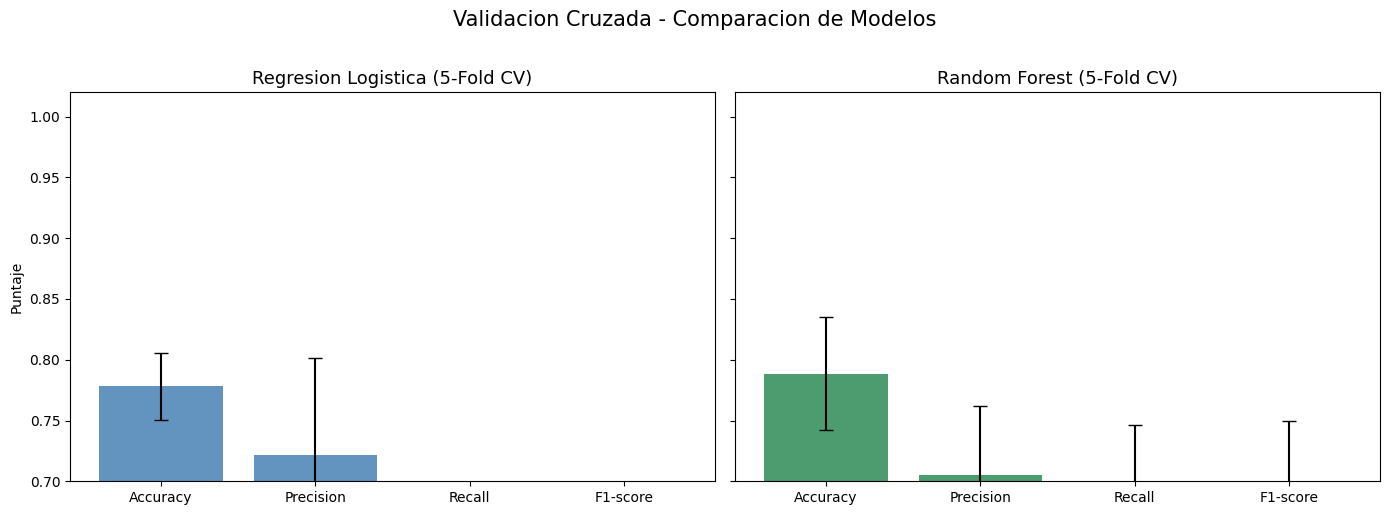

In [58]:
# Visualizacion comparativa de la validacion cruzada
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

metricas = ['accuracy', 'precision', 'recall', 'f1']
etiquetas = ['Accuracy', 'Precision', 'Recall', 'F1-score']

# Regresion Logistica
medias_lr = [cv_lr[f'test_{m}'].mean() for m in metricas]
stds_lr   = [cv_lr[f'test_{m}'].std() for m in metricas]

axes[0].bar(etiquetas, medias_lr, yerr=stds_lr, capsize=5, color='steelblue', alpha=0.85)
axes[0].set_title('Regresion Logistica (5-Fold CV)', fontsize=13)
axes[0].set_ylim(0.7, 1.02)
axes[0].set_ylabel('Puntaje')

# Random Forest
medias_rf = [cv_rf[f'test_{m}'].mean() for m in metricas]
stds_rf   = [cv_rf[f'test_{m}'].std() for m in metricas]

axes[1].bar(etiquetas, medias_rf, yerr=stds_rf, capsize=5, color='seagreen', alpha=0.85)
axes[1].set_title('Random Forest (5-Fold CV)', fontsize=13)

plt.suptitle('Validacion Cruzada - Comparacion de Modelos', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

In [59]:
# Tabla resumen de la validacion cruzada
resumen_cv = pd.DataFrame({
    'Metrica': etiquetas,
    'LR - Media': medias_lr,
    'LR - Desvio': stds_lr,
    'RF - Media': medias_rf,
    'RF - Desvio': stds_rf
})

print('Resumen de Validacion Cruzada (5-Fold):')
display(resumen_cv.style.format({
    'LR - Media': '{:.4f}', 'LR - Desvio': '{:.4f}',
    'RF - Media': '{:.4f}', 'RF - Desvio': '{:.4f}'
}))

Resumen de Validacion Cruzada (5-Fold):


,Metrica,LR - Media,LR - Desvio,RF - Media,RF - Desvio
0,Accuracy,0.7780,0.0278,0.7885,0.0463
1,Precision,0.7220,0.0791,0.7054,0.0567
2,Recall,0.5615,0.1131,0.6077,0.1385
3,F1-score,0.6215,0.0612,0.6484,0.1009


## Análisis Complementario: Ajuste de Umbral de Decisión

El umbral estándar de 0.5 no siempre es el más adecuado. En este contexto, un falso negativo (no detectar un caso posible de diabetes) tiene consecuencias graves. Por eso se explora un umbral más bajo (15 %), priorizando el recall.

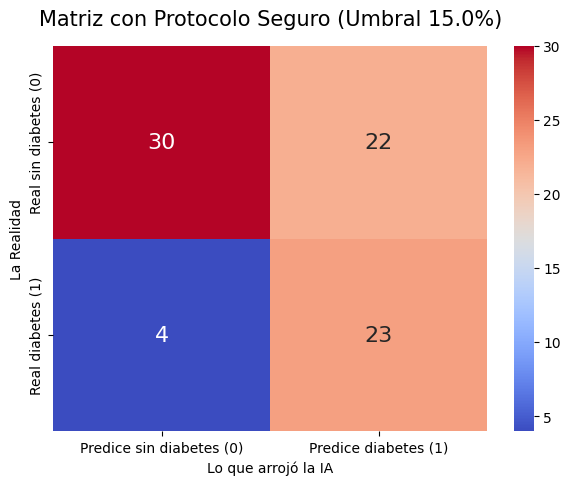

--- NUEVO REPORTE (PROTOCOLO SEGURO) ---
              precision    recall  f1-score   support

           0       0.88      0.58      0.70        52
           1       0.51      0.85      0.64        27

    accuracy                           0.67        79
   macro avg       0.70      0.71      0.67        79
weighted avg       0.76      0.67      0.68        79

Al buscar identificar la mayor cantidad de casos de diabetes posible (Recall alto) se perdió mucha Precisión.


In [60]:
# 1. Extraer los porcentajes exactos de probabilidad de impacto
posible_diabs = modelo_lr.predict_proba(X_test)[:, 1]

# 2. Definir el Protocolo Seguro: Umbral súper sensible (15%)
umbral_seguro = 0.15

# 3. Aplicar la regla: Si la probabilidad es >= 15%, se clasifica como 1 (Diabetes)
y_pred_seguro = (posible_diabs >= umbral_seguro).astype(int)

# 4. Mostrar la nueva Matriz de Confusión sensible
cm_seguro = confusion_matrix(y_test, y_pred_seguro)

plt.figure(figsize=(7,5))
sns.heatmap(cm_seguro, annot=True, fmt='d', cmap='coolwarm', annot_kws={"size": 16},
            xticklabels=['Predice sin diabetes (0)', 'Predice diabetes (1)'],
            yticklabels=['Real sin diabetes (0)', 'Real diabetes (1)'])

plt.title(f'Matriz con Protocolo Seguro (Umbral {umbral_seguro*100}%)', fontsize=15, pad=15)
plt.ylabel('La Realidad')
plt.xlabel('Lo que arrojó la IA')
plt.show()

# 5. Nuevo Reporte de Clasificación
print("--- NUEVO REPORTE (PROTOCOLO SEGURO) ---")
print(classification_report(y_test, y_pred_seguro))

print("Al buscar identificar la mayor cantidad de casos de diabetes posible (Recall alto) se perdió mucha Precisión.")

## Resultados de la Validación Cruzada (5-Fold)

### Contexto: el dataset está desbalanceado

- **66.83%** no son casos de diabetes
- **33.16%** son casos de diabetes

---

###  Regresión Logística

| Métrica | Media | Desvío | Valores por fold |
|---------|-------|--------|------------------|
| Accuracy | 0.7780 | ±0.0278 | [ 0.7975, 0.7722, 0.8205, 0.7564, 0.7436 ] |
| Precision | 0.7220 | ±0.0791 | [ 0.8571, 0.7500, 0.7143, 0.6522, 0.6364 ] |
| Recall | 0.5615 | ±0.1131 | [ 0.4615, 0.4615, 0.7692, 0.5769, 0.5385 ] |
| F1-score | 0.6215 | ±0.0612 | [0.6000, 0.5714, 0.7407, 0.6122, 0.5833 ] |

---

###  Random Forest

| Métrica | Media | Desvío | Valores por fold |
|---------|-------|--------|------------------|
| Accuracy | 0.7885 | ±0.0463 | [ 0.7468, 0.7342, 0.8590, 0.8205, 0.7821 ] |
| Precision | 0.7054 | ±0.0567 | [ 0.6667, 0.6316, 0.8000, 0.7143, 0.7143 ]|
| Recall | 0.6077 | ±0.1385 | [ 0.4615, 0.4615, 0.7692, 0.7692, 0.5769 ] |
| F1-score | 0.6484 | ±0.1009 | [ 0.5455, 0.5333, 0.7843, 0.7407, 0.6383 ] |

---

### Interpretación de las métricas de evaluación

1. La media indica el rendimiento promedio del modelo en las 5 particiones. Es la mejor estimación disponible de cómo se comportaría el modelo con datos nuevos, más confiable que un único train/test split.

2. La desviación estándar indica qué tan consistente es esa media entre folds:

- Ambos modelos tienen desvíos relativamente bajos en Accuracy (±0.028 LR, ±0.046 RF), lo que sugiere que esta métrica es estable independientemente de cómo se particionen los datos.
- El Recall muestra el desvío más alto de las cuatro métricas en ambos modelos (±0.113 LR, ±0.139 RF), lo cual tiene sentido: es la métrica calculada sobre la clase minoritaria (casos positivos de diabetes), así que con menos ejemplos por fold, cada partición pesa más sobre el resultado.

3. Los valores por partición muestran que ninguno de los dos modelos es uniformemente superior en todas las particiones.
- El fold 3 es el más favorable para ambos modelos en casi todas las métricas (Recall de 0.77, tanto en LR como en RF).
- En los folds 1 y 2, LR y RF logran exactamente el mismo Recall (0.4615).
- La ventaja de RF en la media proviene casi por completo de un mejor desempeño en los folds 3 a 5, no de una superioridad uniforme en todas las particiones.

- Esto refuerza que la diferencia entre modelos depende en parte de qué datos caen en cada partición, no solo del algoritmo elegido.
---

### Resumen de evaluación comparativa de modelos
| | Regresión Logística | Random Forest |
|---|---|---|
| ¿Detecta casos de diabetes? |  Detecta poco más de la mitad (56%) |  Detecta un poco más (61%) |
| ¿Cuando dice "diabetes", acierta? | Sí, la mayoría de las veces (72%) | Sí, la mayoría de las veces (71%) |
| ¿Es consistente entre folds? | Estable en Accuracy, variable en Recall | Similar: estable en Accuracy, variable en Recall |
| **Veredicto** | Ligeramente por debajo de RF en Accuracy, Recall y F1 | Ligeramente por encima de LR en Accuracy, Recall y F1, pero dentro del margen de desvío estándar |

Ninguno de los dos modelos se destaca claramente sobre el otro: las diferencias son pequeñas y quedan dentro del rango de variabilidad observado entre folds.

Esto sugiere que, con este tamaño de dataset (392 casos tras la limpieza) y este conjunto de variables, el techo de rendimiento está más determinado por los datos disponibles que por la elección entre estos dos algoritmos.

Dado que ningún modelo se impone claramente sobre el otro, el ajuste del umbral de decisión explorado anteriormente cobra más relevancia como estrategia práctica: en lugar de buscar un modelo "ganador", ajustar el umbral (bajándolo a 15%) permite priorizar el Recall (i.e. minimizar los falsos negativos) que es el error más costoso en un contexto de detección temprana de diabetes.

Esto sugiere que, en este proyecto, la decisión más impactante no fue tanto la elección entre Regresión Logística y Random Forest, sino cómo se calibra el modelo elegido para el objetivo clínico específico.
